#  Task : Emotion Recognition from Speech

- ✅ Data augmentation (noise, pitch shift, time stretch) → ~5x more training data
- ✅ Delta + Delta-Delta MFCCs for richer temporal features
- ✅ Class weights to fix imbalance
- ✅ L2 regularization to reduce overfitting
- ✅ Cosine annealing learning rate schedule
- ✅ Deeper CNN-BiLSTM architecture



## 1. Install Dependencies

In [1]:
!pip install librosa soundfile tensorflow scikit-learn matplotlib seaborn tqdm

## 2. Imports

In [2]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Conv1D, MaxPooling1D,
    BatchNormalization, Bidirectional, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Download RAVDESS Dataset

In [3]:
import zipfile, urllib.request

DATASET_URL = "https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip"
ZIP_PATH    = "/content/ravdess.zip"
DATA_DIR    = "/content/ravdess"

if not os.path.exists(DATA_DIR):
    print("Downloading RAVDESS  ...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)
    print("Extracting ...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present.")

Extracting ...
Done.


## 4. Audio Augmentation Functions

In [4]:
def augment_audio(y, sr):
    """
    Returns a list of augmented versions of the audio signal.
    Techniques: additive noise, pitch shift up/down, time stretch fast/slow.
    """
    augmented = []

    # 1. Add white noise
    noise = y + 0.005 * np.random.randn(len(y))
    augmented.append(noise)

    # 2. Pitch shift up by 2 semitones
    try:
        augmented.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=2))
    except Exception:
        pass

    # 3. Pitch shift down by 2 semitones
    try:
        augmented.append(librosa.effects.pitch_shift(y, sr=sr, n_steps=-2))
    except Exception:
        pass

    # 4. Time stretch faster
    try:
        stretched = librosa.effects.time_stretch(y, rate=1.1)
        augmented.append(stretched)
    except Exception:
        pass

    # 5. Time stretch slower
    try:
        stretched = librosa.effects.time_stretch(y, rate=0.9)
        augmented.append(stretched)
    except Exception:
        pass

    return augmented

## 5. Feature Extraction (MFCCs + Deltas + Chroma + Mel)

In [5]:
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def extract_features(y, sr, n_mfcc=40, n_chroma=12, max_pad_len=174):
    """
    Extract MFCCs + Delta MFCCs + Delta-Delta MFCCs + Chroma + Mel.
    Returns shape: (max_pad_len, n_features)
    """
    try:
        # MFCCs and their deltas -> (40, T), (40, T), (40, T)
        mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfcc_delta  = librosa.feature.delta(mfcc)
        mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

        # Chroma -> (12, T)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=n_chroma)

        # Mel top-20 bands -> (20, T)
        mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_db = librosa.power_to_db(mel, ref=np.max)[:20, :]

        # Stack all -> (112, T)
        combined = np.vstack([mfcc, mfcc_delta, mfcc_delta2, chroma, mel_db])

        # Pad / truncate time axis to max_pad_len
        if combined.shape[1] < max_pad_len:
            pad = max_pad_len - combined.shape[1]
            combined = np.pad(combined, ((0, 0), (0, pad)), mode="constant")
        else:
            combined = combined[:, :max_pad_len]

        return combined.T   # -> (174, 112)
    except Exception as e:
        print(f"Feature extraction error: {e}")
        return None

## 6. Build Dataset with Augmentation

In [7]:
def load_ravdess_augmented(data_dir, augment=True):
    X, y = [], []
    wav_files = []

    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.endswith(".wav"):
                wav_files.append(os.path.join(root, f))

    for path in tqdm(wav_files, desc="Processing audio files"):
        fname = os.path.basename(path)
        parts = fname.split("-")
        if len(parts) < 3:
            continue
        emotion_code = parts[2]
        emotion = EMOTION_MAP.get(emotion_code)
        if emotion is None:
            continue

        try:
            audio, sr = librosa.load(path, sr=22050, mono=True)
        except Exception as e:
            print(f"Load error {path}: {e}")
            continue

        # Original
        feat = extract_features(audio, sr)
        if feat is not None:
            X.append(feat)
            y.append(emotion)

        # Augmented versions
        if augment:
            for aug_audio in augment_audio(audio, sr):
                feat = extract_features(aug_audio, sr)
                if feat is not None:
                    X.append(feat)
                    y.append(emotion)

    return np.array(X, dtype=np.float32), np.array(y)

print("Loading and augmenting dataset ...")
X, y_labels = load_ravdess_augmented(DATA_DIR, augment=True)
print(f"\nFinal dataset: X={X.shape}, y={y_labels.shape}")
print("Samples per emotion:", {e: int(np.sum(y_labels == e)) for e in np.unique(y_labels)})

Loading and augmenting dataset ...


Processing audio files: 100%|██████████| 1440/1440 [09:07<00:00,  2.63it/s]



Final dataset: X=(8640, 174, 152), y=(8640,)
Samples per emotion: {np.str_('angry'): 1152, np.str_('calm'): 1152, np.str_('disgust'): 1152, np.str_('fearful'): 1152, np.str_('happy'): 1152, np.str_('neutral'): 576, np.str_('sad'): 1152, np.str_('surprised'): 1152}


## 7. Normalize Features

In [8]:
# Normalize across the feature dimension
X_mean = X.mean(axis=(0, 1), keepdims=True)
X_std  = X.std(axis=(0, 1), keepdims=True) + 1e-8
X_norm = (X - X_mean) / X_std
print("Normalized. Shape:", X_norm.shape)

Normalized. Shape: (8640, 174, 152)


## 8. Encode Labels & Split

In [9]:
le    = LabelEncoder()
y_enc = le.fit_transform(y_labels)
y_cat = to_categorical(y_enc)
NUM_CLASSES = len(le.classes_)
print("Classes:", le.classes_)

X_train, X_test, y_train, y_test, y_train_enc, y_test_enc = train_test_split(
    X_norm, y_cat, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Train: (6220, 174, 152)  Val: (692, 174, 152)  Test: (1728, 174, 152)


## 9. Compute Class Weights

In [10]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_enc),
    y=y_train_enc
)
class_weight_dict = dict(enumerate(class_weights_arr))
print("Class weights:")
for idx, w in class_weight_dict.items():
    print(f"  {le.classes_[idx]:<12} -> {w:.3f}")

Class weights:
  angry        -> 0.937
  calm         -> 0.937
  disgust      -> 0.937
  fearful      -> 0.938
  happy        -> 0.938
  neutral      -> 1.874
  sad          -> 0.937
  surprised    -> 0.938


## 10. Build Improved CNN-BiLSTM Model

In [11]:
def build_model(input_shape, num_classes):
    model = Sequential([
        # --- CNN Block 1 ---
        Conv1D(64, kernel_size=5, activation="relu", padding="same",
               input_shape=input_shape),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # --- CNN Block 2 ---
        Conv1D(128, kernel_size=5, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # --- CNN Block 3 (new) ---
        Conv1D(256, kernel_size=3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # --- Bidirectional LSTM ---
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.4),

        # --- Classifier head with L2 regularization ---
        Dense(256, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.4),
        Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.3),
        Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=NUM_CLASSES
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 174, 64)        │        48,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 174, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 87, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 43, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 43, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 43, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 21, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 21, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 815,688 (3.11 MB)

 Trainable params: 814,792 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)

## 11. Train the Model

In [12]:
# Cosine annealing learning rate
def cosine_annealing(epoch, lr):
    import math
    T_max = 60
    eta_min = 1e-6
    eta_max = 1e-3
    return eta_min + 0.5 * (eta_max - eta_min) * (1 + math.cos(math.pi * epoch / T_max))

callbacks = [
    EarlyStopping(monitor="val_loss", patience=12,
                  restore_best_weights=True, verbose=1),
    LearningRateScheduler(cosine_annealing, verbose=0),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
)

Epoch 1/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.2780 - loss: 2.1358 - val_accuracy: 0.3497 - val_loss: 1.9033 - learning_rate: 0.0010
Epoch 2/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.4460 - loss: 1.7219 - val_accuracy: 0.4509 - val_loss: 1.6880 - learning_rate: 9.9932e-04
Epoch 3/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.5293 - loss: 1.4837 - val_accuracy: 0.5448 - val_loss: 1.3732 - learning_rate: 9.9726e-04
Epoch 4/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5841 - loss: 1.2885 - val_accuracy: 0.6156 - val_loss: 1.2024 - learning_rate: 9.9385e-04
Epoch 5/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6397 - loss: 1.1592 - val_accuracy: 0.6503 - val_loss: 1.1099 - learning_rate: 9.8908e-04
Epoch 6/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6717 - loss: 1.0434 - val_accuracy: 0.6965 - val_loss: 1.0363 - learning_rate: 9.8298e-04
Epoch 7/60
195/195 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accura

## 12. Plot Training Curves

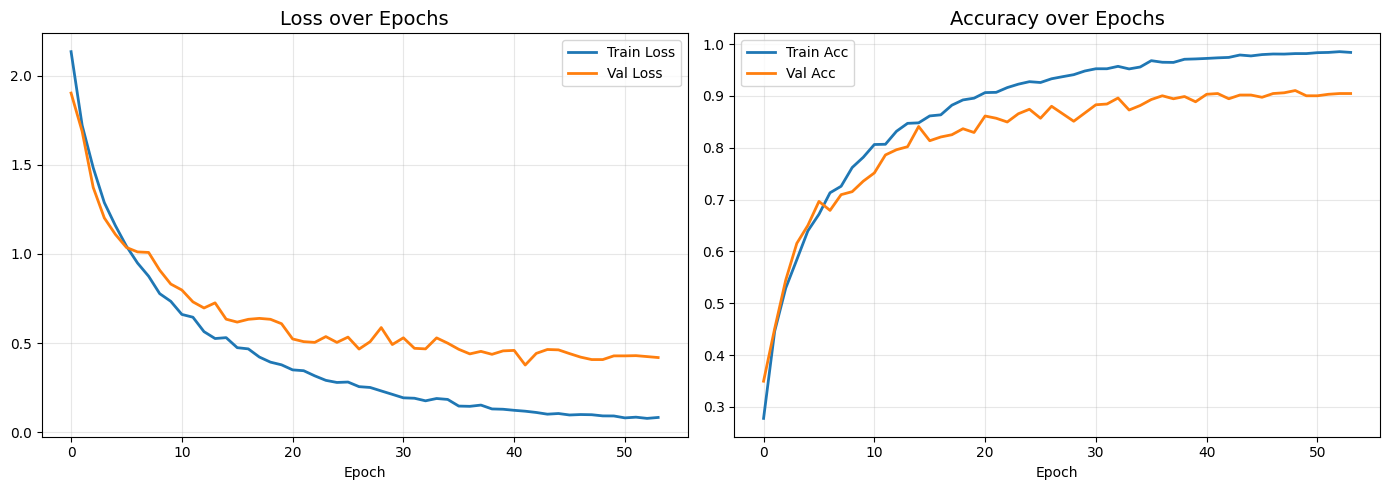

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["loss"],     label="Train Loss", linewidth=2)
axes[0].plot(history.history["val_loss"], label="Val Loss",   linewidth=2)
axes[0].set_title("Loss over Epochs", fontsize=14)
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["accuracy"],     label="Train Acc", linewidth=2)
axes[1].plot(history.history["val_accuracy"], label="Val Acc",   linewidth=2)
axes[1].set_title("Accuracy over Epochs", fontsize=14)
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves_v2.png", dpi=150)
plt.show()

## 13. Evaluate on Test Set

In [14]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Test Accuracy : {acc*100:.2f}%")
print(f"  Test Loss     : {loss:.4f}")
print(f"{'='*40}\n")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test,       axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))


  Test Accuracy : 91.67%
  Test Loss     : 0.3372

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
Classification Report:
              precision    recall  f1-score   support

       angry       0.96      0.96      0.96       230
        calm       0.92      0.94      0.93       230
     disgust       0.95      0.91      0.93       230
     fearful       0.95      0.92      0.93       231
       happy       0.89      0.87      0.88       231
     neutral       0.79      0.90      0.84       115
         sad       0.86      0.89      0.87       230
   surprised       0.97      0.94      0.95       231

    accuracy                           0.92      1728
   macro avg       0.91      0.92      0.91      1728
weighted avg       0.92      0.92      0.92      1728



## 14. Confusion Matrix

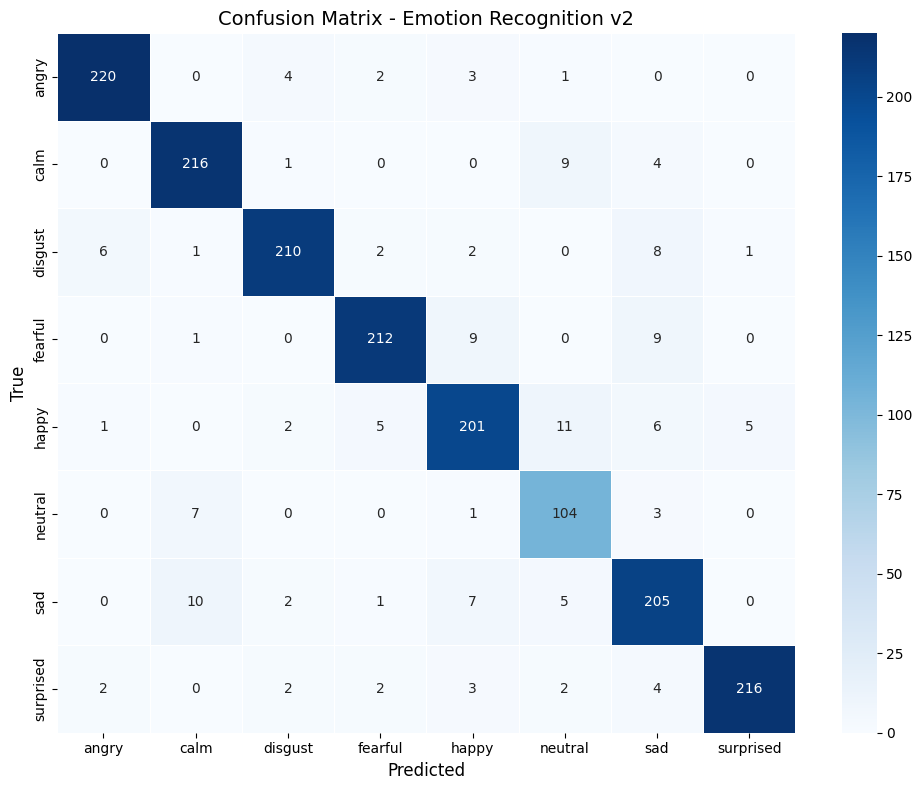

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues", linewidths=0.5)
plt.title("Confusion Matrix - Emotion Recognition v2", fontsize=14)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True",      fontsize=12)
plt.tight_layout()
plt.savefig("/content/confusion_matrix_v2.png", dpi=150)
plt.show()

## 15. Per-Class Accuracy Bar Chart

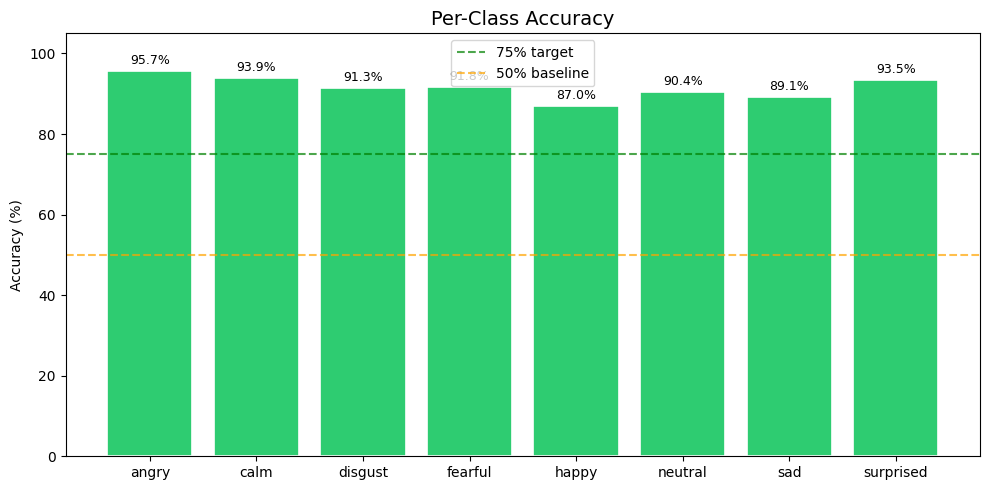

In [16]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#2ecc71' if a >= 0.75 else '#e67e22' if a >= 0.5 else '#e74c3c'
          for a in per_class_acc]

plt.figure(figsize=(10, 5))
bars = plt.bar(le.classes_, per_class_acc * 100, color=colors, edgecolor='white', linewidth=1.2)
plt.axhline(y=75, color='green',  linestyle='--', alpha=0.7, label='75% target')
plt.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='50% baseline')
plt.ylim(0, 105)
plt.title("Per-Class Accuracy", fontsize=14)
plt.ylabel("Accuracy (%)")
plt.legend()
for bar, acc_val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc_val*100:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig("/content/per_class_accuracy_v2.png", dpi=150)
plt.show()

## 16. Predict Emotion on Any Audio File

In [17]:
def predict_emotion(file_path, model, le, X_mean, X_std, max_pad_len=174):
    """Predict emotion from a .wav file path."""
    try:
        audio, sr = librosa.load(file_path, sr=22050, mono=True)
    except Exception as e:
        print(f"Could not load file: {e}")
        return None

    feat = extract_features(audio, sr, max_pad_len=max_pad_len)
    if feat is None:
        return None

    feat_norm = (feat - X_mean.squeeze()) / (X_std.squeeze() + 1e-8)
    feat_norm = np.expand_dims(feat_norm, axis=0)   # (1, T, F)

    probs      = model.predict(feat_norm, verbose=0)[0]
    pred_idx   = np.argmax(probs)
    pred_label = le.classes_[pred_idx]
    confidence = probs[pred_idx] * 100

    print(f"\n Predicted: {pred_label.upper()} ({confidence:.1f}% confidence)\n")
    for cls, p in sorted(zip(le.classes_, probs), key=lambda x: -x[1]):
        bar = "█" * int(p * 40)
        print(f"  {cls:<12} {bar:<40} {p*100:5.1f}%")
    return pred_label

# Example — replace with any .wav file you upload to Colab:
# predict_emotion("/content/ravdess/Actor_01/03-01-05-01-01-01-01.wav",
#                 model, le, X_mean, X_std)
print("predict_emotion() ready. Upload a .wav and pass its path above.")

predict_emotion() ready. Upload a .wav and pass its path above.


## 17. Save the Model

In [18]:
MODEL_PATH = "/content/emotion_recognition_v2.keras"
model.save(MODEL_PATH)
print(f"Model saved: {MODEL_PATH}")

import numpy as np
np.save("/content/X_mean.npy", X_mean)
np.save("/content/X_std.npy",  X_std)
print("Normalization stats saved.")

# To reload later:
# from tensorflow.keras.models import load_model
# model  = load_model("/content/emotion_recognition_v2.keras")
# X_mean = np.load("/content/X_mean.npy")
# X_std  = np.load("/content/X_std.npy")

Model saved: /content/emotion_recognition_v2.keras
Normalization stats saved.
